#Heart Failure Prediction Project

In [188]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set(font_scale=1.1)
from google.colab import files

In [189]:
#upload
uploaded=files.upload()
#kaggle file name
df=pd.read_csv('heart.csv')
df.head()

Saving heart.csv to heart (7).csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [190]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [191]:
print('shape',df.shape)
print('info')
df.info()

shape (918, 12)
info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


#statistic for numerical

In [192]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


#target ans feature  type / objec= category / int folat= numeric

In [193]:
target_Col='HeartDisease'
numeric_col=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']  #,'HeartDisease'
categorical_cols=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

print(target_Col)
print(numeric_col)
print(categorical_cols)

HeartDisease
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


#cheack missing vbvalues count per colum

In [194]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


#look at some basic value ranges

In [195]:
df[numeric_col].agg(['min','max', 'mean', 'median']).T

,min,max,mean,median
Age,28.0,77.0,53.510893,54.0
RestingBP,0.0,200.0,132.396514,130.0
Cholesterol,0.0,603.0,198.799564,223.0
FastingBS,0.0,1.0,0.233115,0.0
MaxHR,60.0,202.0,136.809368,138.0
Oldpeak,-2.6,6.2,0.887364,0.6


In [196]:
for c in categorical_cols:
  print(c,df[c].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


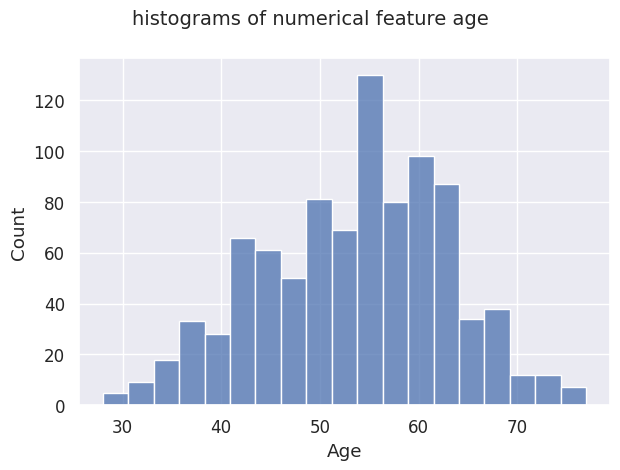

In [197]:
# df['Age'].hist(bins=20,figsize=(8,4))
#use seaborn
import seaborn as sns
sns.histplot(data=df,x='Age')
plt.suptitle('histograms of numerical feature age', fontsize= 14)
plt.tight_layout()
plt.show()

#histogrms

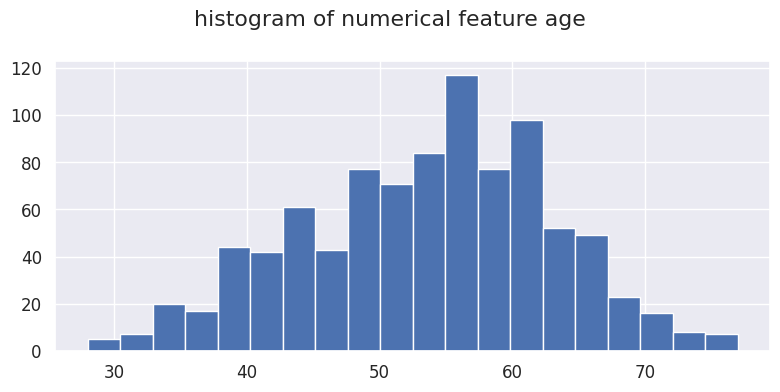

In [198]:
df['Age'].hist(bins=20,figsize=(8,4))
plt.suptitle('histogram of numerical feature age')
plt.tight_layout()
plt.show()

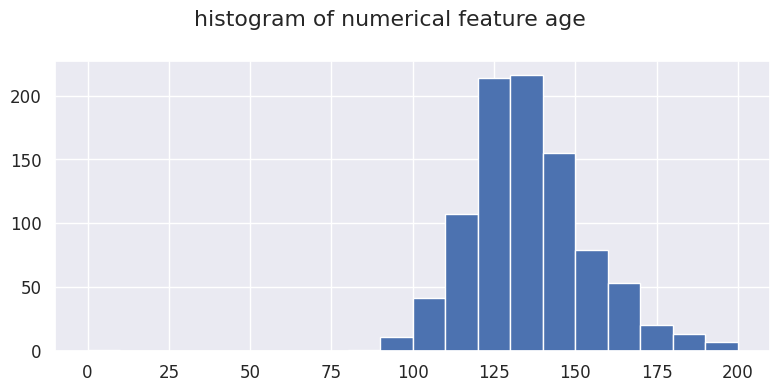

In [199]:
#histogrms
df['RestingBP'].hist(bins=20,figsize=(8,4))
plt.suptitle('histogram of numerical feature age')
plt.tight_layout()
plt.show()

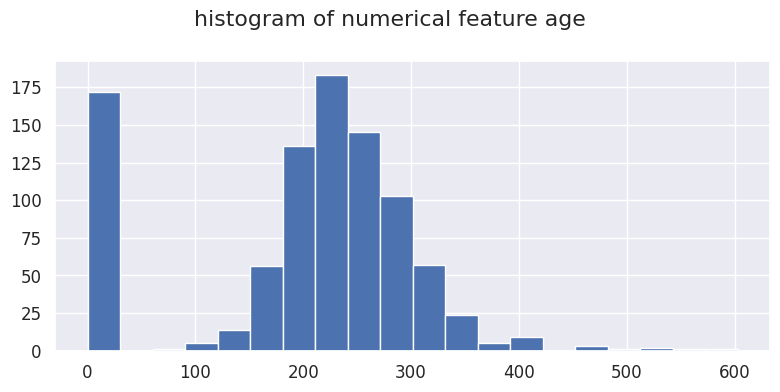

In [200]:
#histogrms
df['Cholesterol'].hist(bins=20,figsize=(8,4))
plt.suptitle('histogram of numerical feature age')
plt.tight_layout()
plt.show()

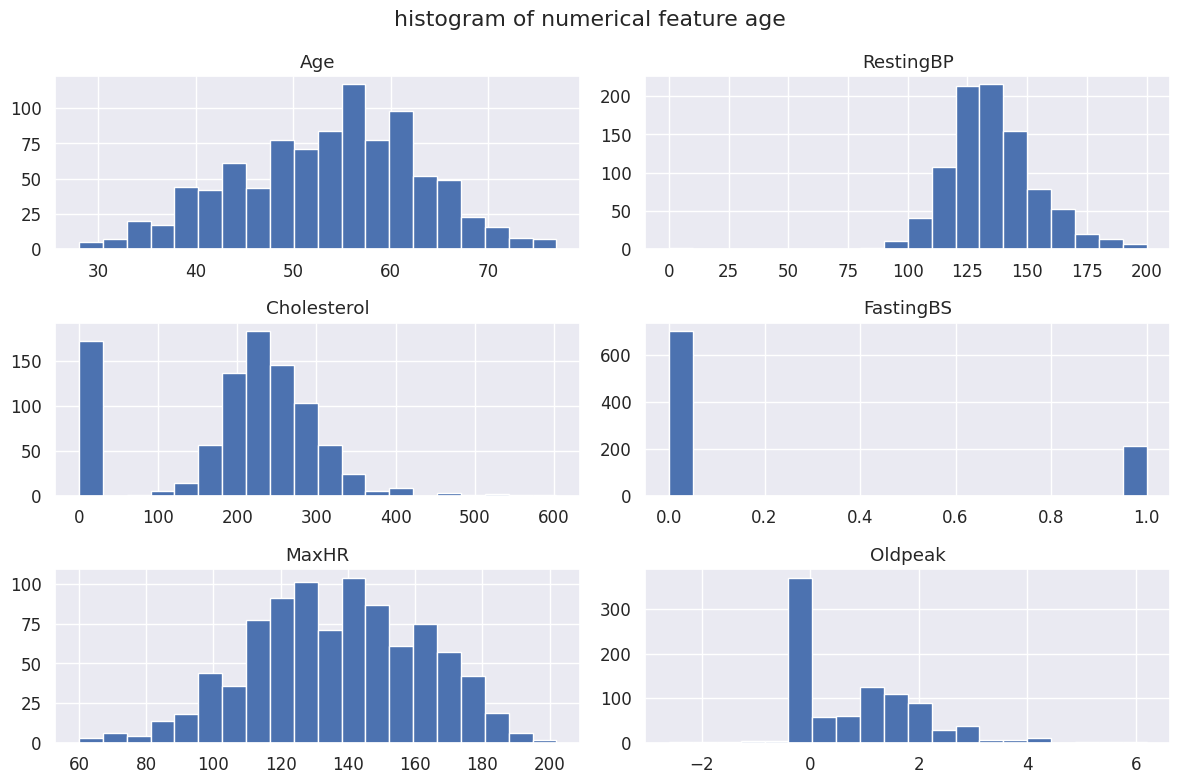

In [201]:
#histogrms
df[numeric_col].hist(bins=20,figsize=(12,8))
plt.suptitle('histogram of numerical feature age')
plt.tight_layout()
plt.show()

#boxplot

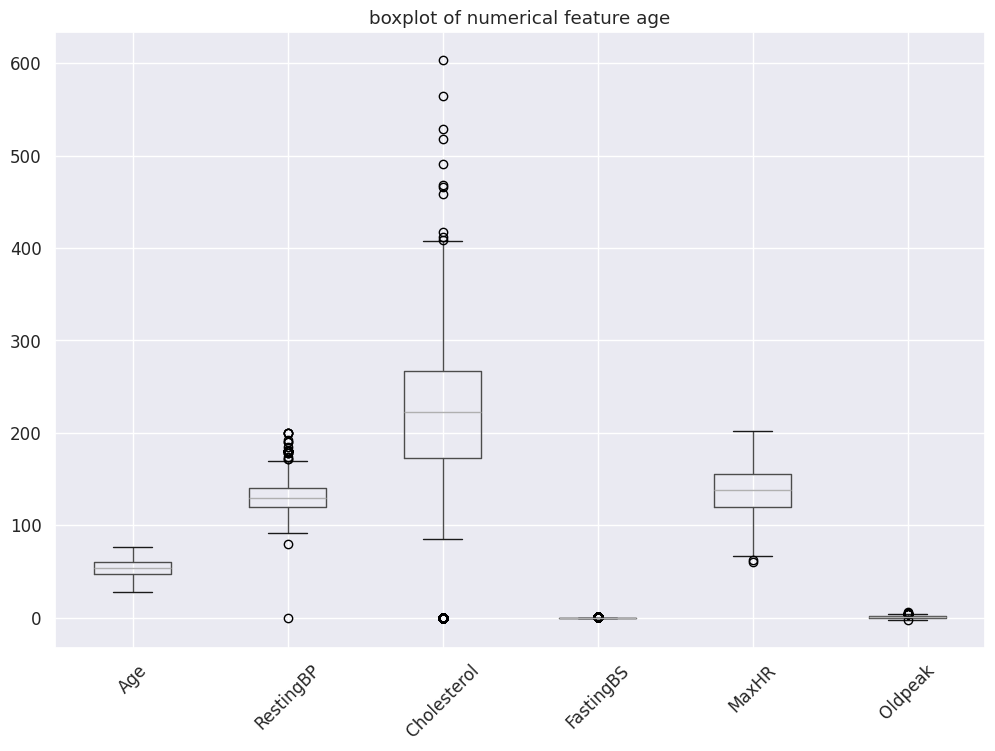

In [202]:
plt.figure(figsize=(12,8))
df[numeric_col].boxplot()
plt.title('boxplot of numerical feature age')
plt.xticks(rotation=45)
plt.show()

#target distribustion

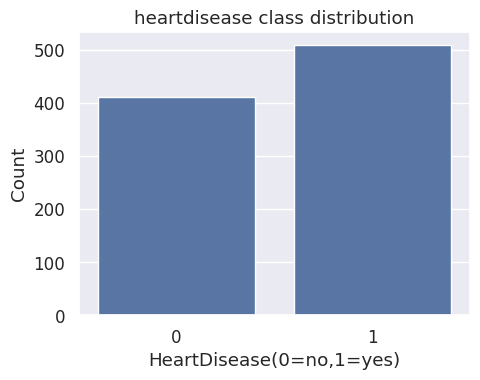

In [203]:
plt.figure(figsize=(5,4))
sns.countplot(x=df[target_Col])
plt.title('heartdisease class distribution')
plt.xlabel('HeartDisease(0=no,1=yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [204]:
df[target_Col].value_counts(normalize=True)

,proportion
HeartDisease,
1,0.553377
0,0.446623


#categorical value plot

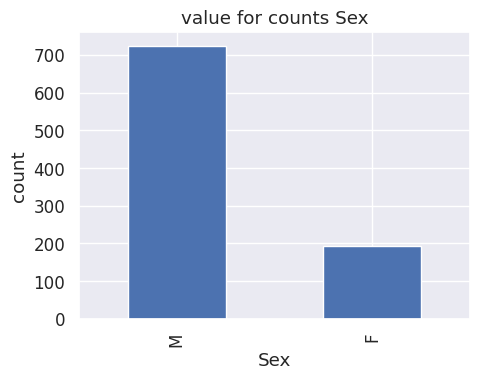

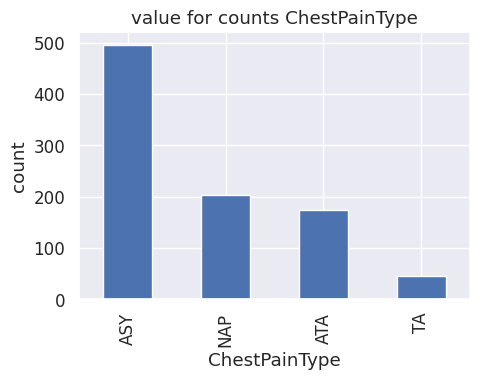

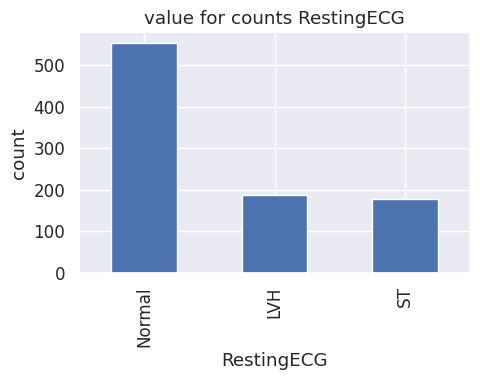

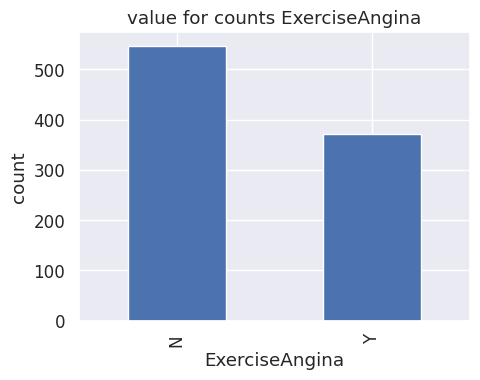

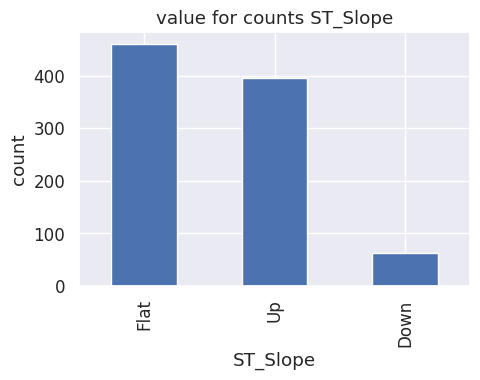

In [205]:
for c in categorical_cols:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind='bar')
  plt.title(f'value for counts {c}')
  plt.ylabel('count')
  plt.tight_layout()
  plt.show()

#boxplots of numeric feature split by heartd

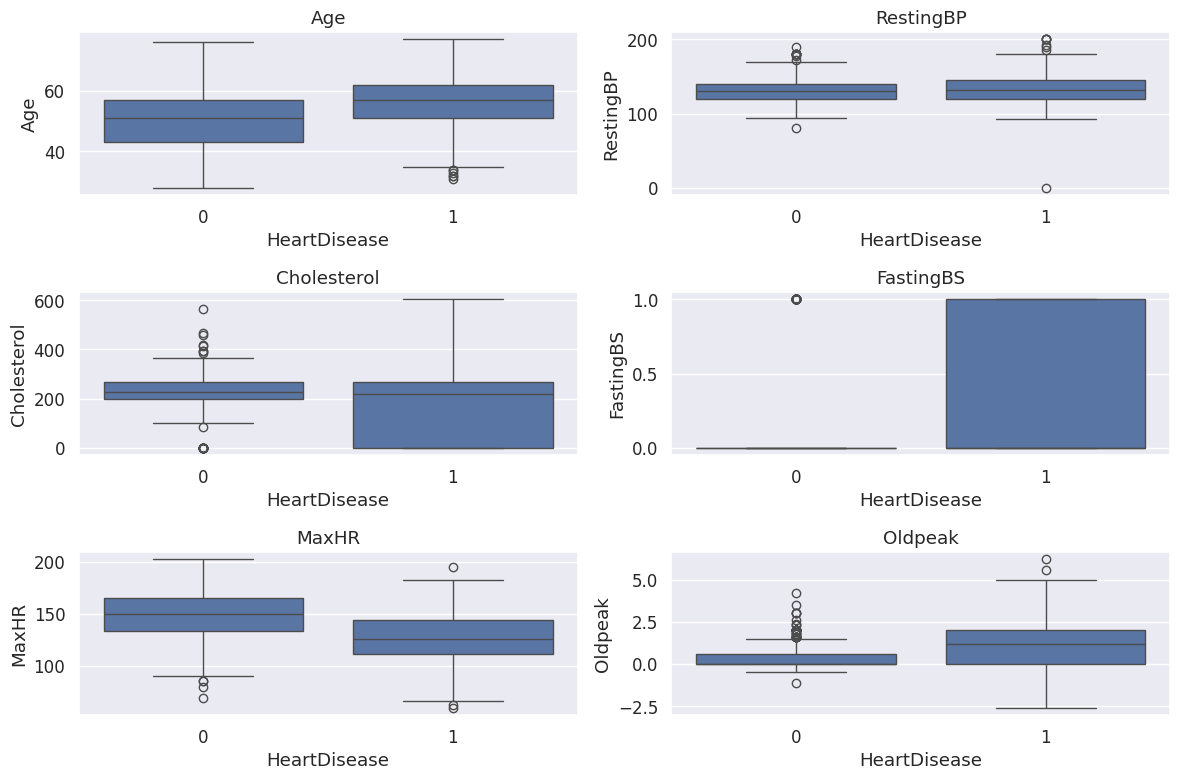

In [206]:
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_col,1):
  plt.subplot(3, 2, i)
  sns.boxplot(x=df[target_Col],y=df[col])
  plt.title(col)
plt.tight_layout()
plt.show()

#pairplot for a subset of features

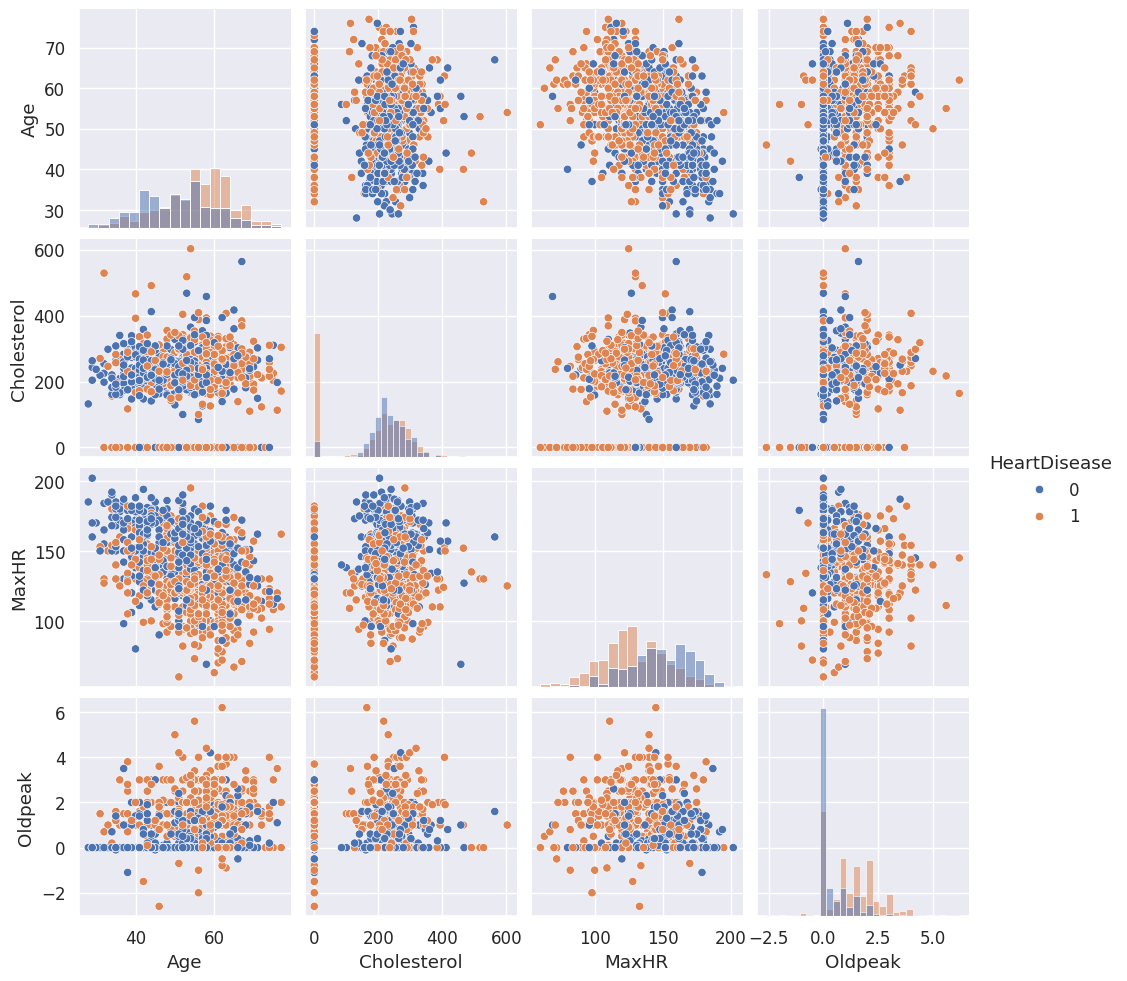

In [207]:
sns.pairplot(df[['Age','Cholesterol','MaxHR','Oldpeak','HeartDisease']],hue='HeartDisease',diag_kind='hist')
plt.show()

#correlation matrix and heatmap

Text(0.5, 1.0, 'correlation Heatmap for numerical features')

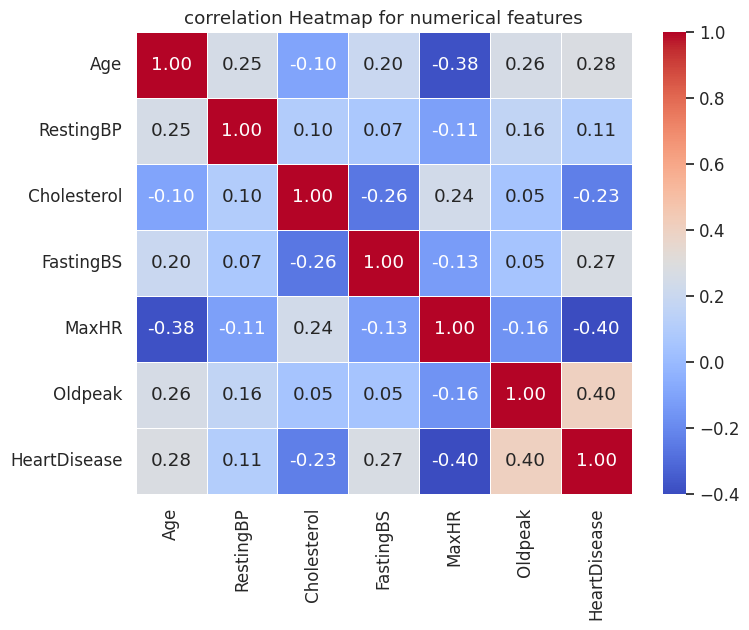

In [208]:
corr_matrix=df[numeric_col+[target_Col]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('correlation Heatmap for numerical features')

In [209]:
corr_matrix[target_Col].sort_values(ascending=False)

,HeartDisease
HeartDisease,1.000000
Oldpeak,0.403951
Age,0.282039
FastingBS,0.267291
RestingBP,0.107589
Cholesterol,-0.232741
MaxHR,-0.400421


#categorical feature and target


 Proportion of heartdisease within Sex


HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


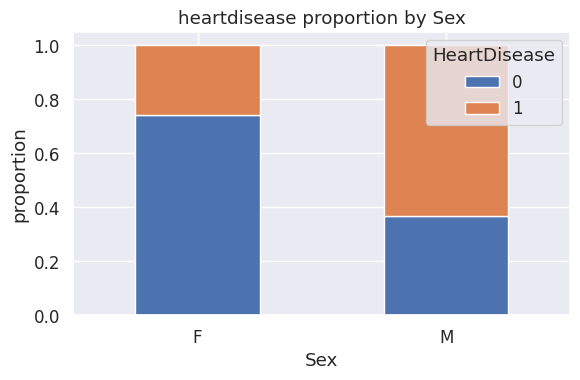


 Proportion of heartdisease within ChestPainType


HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


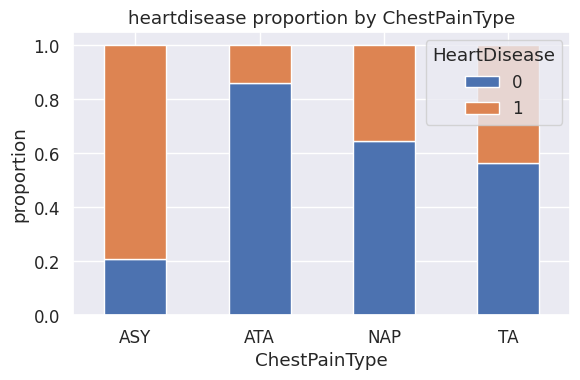


 Proportion of heartdisease within RestingECG


HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


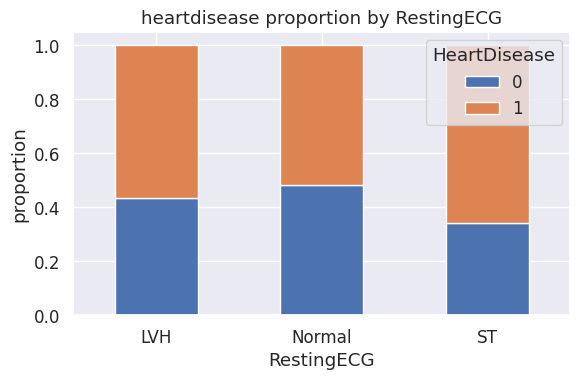


 Proportion of heartdisease within ExerciseAngina


HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


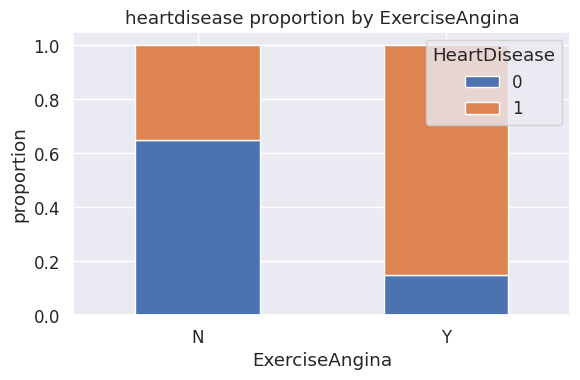


 Proportion of heartdisease within ST_Slope


HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


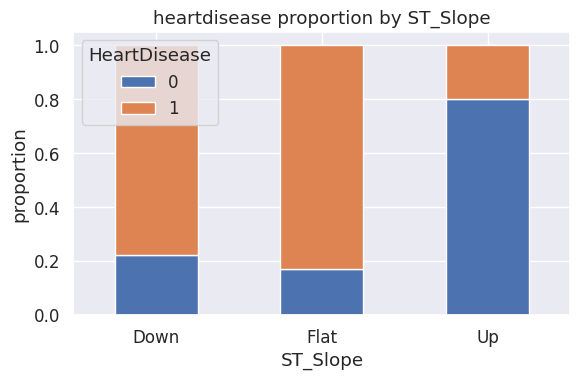

In [210]:
for c in categorical_cols:
  ct=pd.crosstab(df[c],df[target_Col], normalize='index')
  print(f'\n Proportion of heartdisease within {c}')
  display(ct)
  ct.plot(kind='bar',stacked=True, figsize=(6,4))
  plt.title(f'heartdisease proportion by {c}')
  plt.ylabel('proportion')
  plt.xticks(rotation=0)
  plt.tight_layout()
  plt.show()